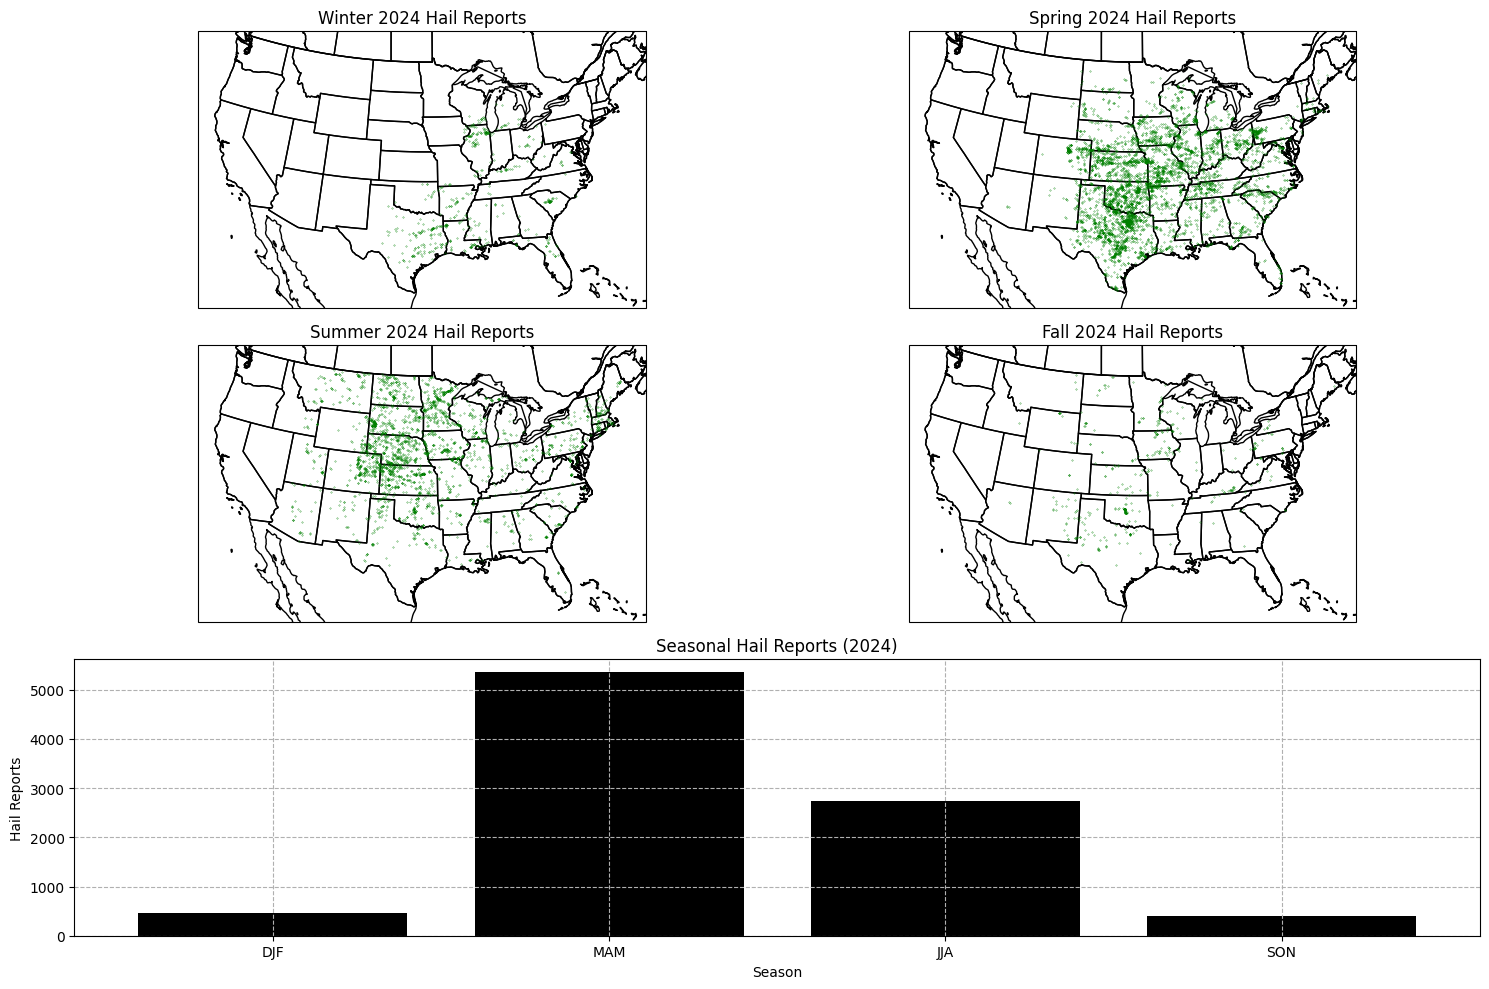

In [20]:
#import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#read in the file
hail = pd.read_csv("1955-2024_hail.csv")

#filter data to 2024
hail_24 = hail[(hail['yr'] == 2024)]

#filtering for lat and long east of the Continental Divide using the already filtered year and diameter data
hail_ec_24 = hail_24[(hail_24['slat'] >= 24.5) & (hail_24['slat'] <= 49) & (hail_24['slon'] >= -113) & (hail_24['slon'] <= -66.9)]

#filtering for season
winter = hail_ec_24[(hail_ec_24['mo']== 12) | (hail_ec_24['mo'] == 1) | (hail_ec_24['mo'] == 2)]
spring = hail_ec_24[(hail_ec_24['mo']== 3) | (hail_ec_24['mo'] == 4) | (hail_ec_24['mo'] == 5)]
summer = hail_ec_24[(hail_ec_24['mo']== 6) | (hail_ec_24['mo'] == 7) | (hail_ec_24['mo'] == 8)]
fall = hail_ec_24[(hail_ec_24['mo']== 9) | (hail_ec_24['mo'] == 10) | (hail_ec_24['mo'] == 11)]

#seasonal counts
season_count = [len(winter), len(spring), len(summer), len(fall)]

plt.rcParams['figure.figsize'] = 15,10

#plotting
ax00 = plt.subplot(3, 2, 1, projection=ccrs.LambertConformal())
ax00.set_extent([-120, -73, 22, 50])
ax00.set_title("Winter 2024 Hail Reports")

ax00.add_feature(cfeature.BORDERS)
ax00.add_feature(cfeature.COASTLINE)
ax00.add_feature(cfeature.STATES)

ax00.plot(winter.slon, winter.slat, 'g.', markersize=0.5, transform=ccrs.PlateCarree())

ax01 = plt.subplot(3, 2, 2, projection=ccrs.LambertConformal())
ax01.set_extent([-120, -73, 22, 50])
ax01.set_title("Spring 2024 Hail Reports")

ax01.add_feature(cfeature.BORDERS)
ax01.add_feature(cfeature.COASTLINE)
ax01.add_feature(cfeature.STATES)

ax01.plot(spring.slon, spring.slat, 'g.', markersize=0.5, transform=ccrs.PlateCarree())

ax11 = plt.subplot(3, 2, 3, projection=ccrs.LambertConformal())
ax11.set_extent([-120, -73, 22, 50])
ax11.set_title("Summer 2024 Hail Reports")

ax11.add_feature(cfeature.BORDERS)
ax11.add_feature(cfeature.COASTLINE)
ax11.add_feature(cfeature.STATES)

ax11.plot(summer.slon, summer.slat, 'g.', markersize=0.5, transform=ccrs.PlateCarree())

ax12 = plt.subplot(3, 2, 4, projection=ccrs.LambertConformal())
ax12.set_extent([-120, -73, 22, 50])
ax12.set_title("Fall 2024 Hail Reports")

ax12.add_feature(cfeature.BORDERS)
ax12.add_feature(cfeature.COASTLINE)
ax12.add_feature(cfeature.STATES)

ax12.plot(fall.slon, fall.slat, 'g.', markersize=0.5, transform=ccrs.PlateCarree())


#season names for x axis
season_name = ['DJF', 'MAM', 'JJA', 'SON']

ax_bar = plt.subplot(3, 2, (5,6))

ax_bar.bar(season_name, season_count, color='black')
ax_bar.set_xlabel("Season")
ax_bar.set_ylabel("Hail Reports")
ax_bar.set_title("Seasonal Hail Reports (2024)")
ax_bar.grid(linestyle='dashed')


plt.tight_layout()
plt.savefig('2024_Hail_Reports.jpg', dpi=300)
plt.show()
